In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
brands = pd.read_csv("brands.csv")
categories = pd.read_csv("categories.csv")
customers = pd.read_csv("customers.csv")
order_items = pd.read_csv("order_items.csv")
orders = pd.read_csv("orders.csv")
products = pd.read_csv("products.csv")
staffs = pd.read_csv("staffs.csv")
stocks = pd.read_csv("stocks.csv")
stores = pd.read_csv("stores.csv")

In [27]:
customers.shape[0]

1445

In [28]:
stores['store_id'].nunique()

3

In [29]:
orders.shape[0]

1615

In [30]:
products['product_id'].nunique()

321

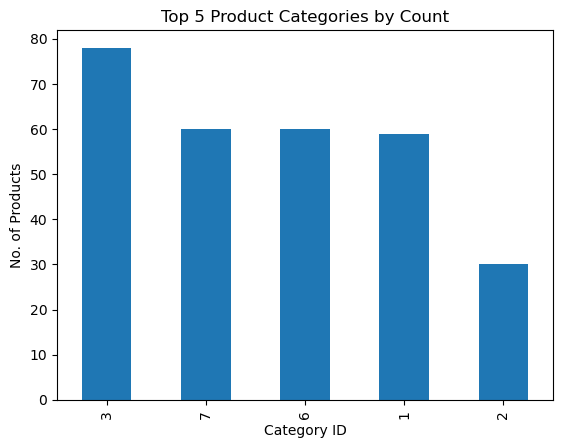

In [31]:
top_cats = products['category_id'].value_counts().head(5)
top_cats.plot(kind='bar', title='Top 5 Product Categories by Count')
plt.xlabel('Category ID'); plt.ylabel('No. of Products'); plt.show()

In [32]:
staffs.shape[0]

10

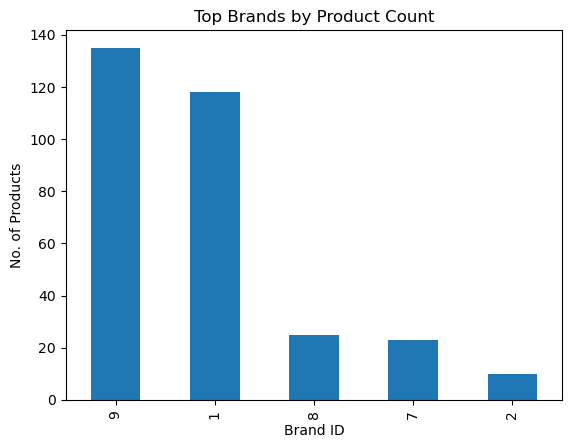

In [33]:
brand_count = products['brand_id'].value_counts().head(5)
brand_count.plot(kind='bar', title='Top Brands by Product Count')
plt.xlabel('Brand ID'); plt.ylabel('No. of Products'); plt.show()

In [34]:
stores[['store_id', 'store_name', 'city']]

,store_id,store_name,city
0,1,Santa Cruz Bikes,Santa Cruz
1,2,Baldwin Bikes,Baldwin
2,3,Rowlett Bikes,Rowlett


In [35]:
avg_products_per_cat = products.groupby('category_id')['product_id'].count().mean()
avg_products_per_cat

45.857142857142854

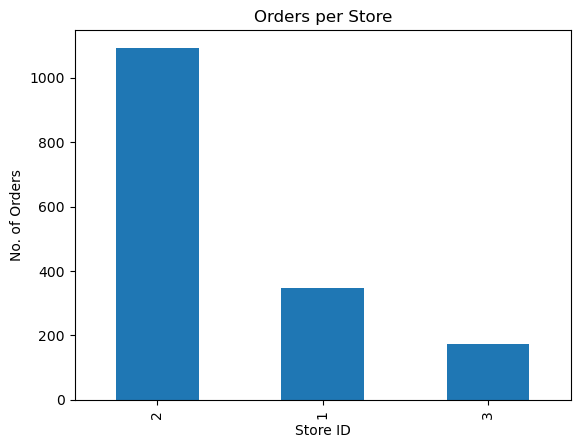

In [36]:
store_orders = orders['store_id'].value_counts()
store_orders.plot(kind='bar', title='Orders per Store')
plt.xlabel('Store ID'); plt.ylabel('No. of Orders'); plt.show()

<Axes: xlabel='city'>

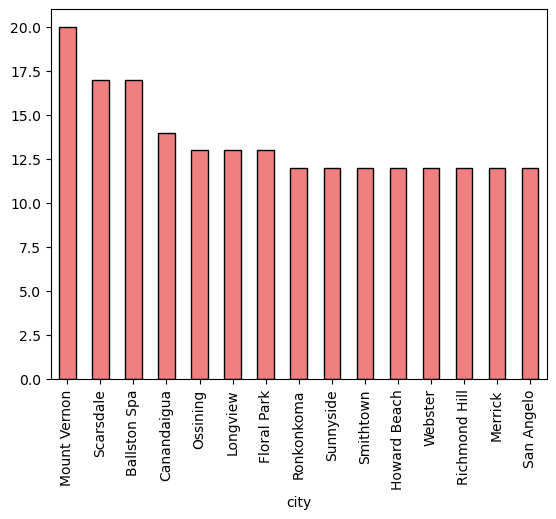

In [38]:
customers['city'].value_counts().head(15).plot(kind='bar', color='lightcoral', edgecolor='black')

In [39]:
order_items.shape[0]

4722

In [40]:
order_items['list_price'].mean()

1212.7078716645487

In [41]:
staffs['manager_id'].notnull().sum()

9

In [ ]:
intermediate questions

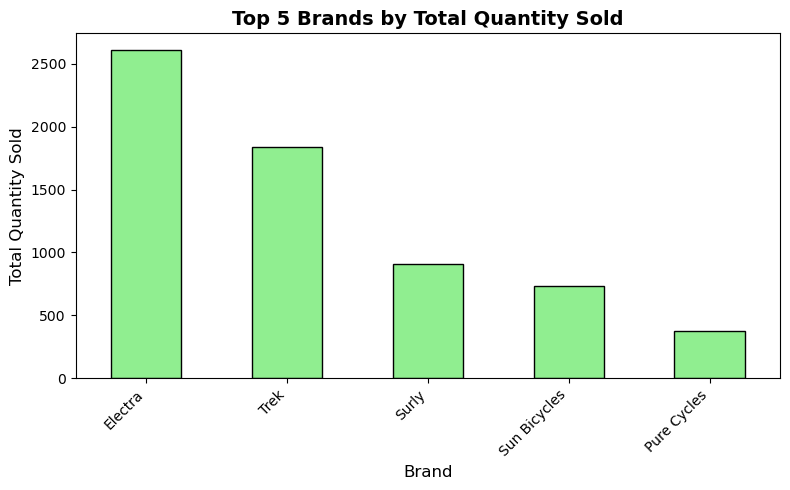

In [47]:
merged_brand = order_items.merge(products, on='product_id').merge(brands, on='brand_id')
brand_sales_qty = merged_brand.groupby('brand_name')['quantity'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(8,5))
brand_sales_qty.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Top 5 Brands by Total Quantity Sold', fontsize=14, fontweight='bold')
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

Text(0, 0.5, 'No. of Orders')

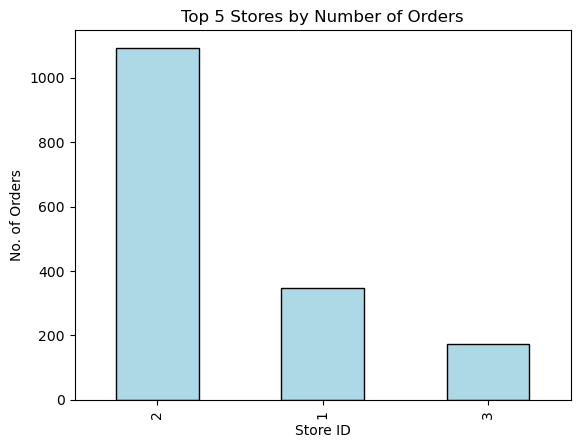

In [49]:
orders['store_id'].value_counts().head(5).plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Top 5 Stores by Number of Orders')
plt.xlabel('Store ID')
plt.ylabel('No. of Orders')

Text(0, 0.5, 'No. of Orders')

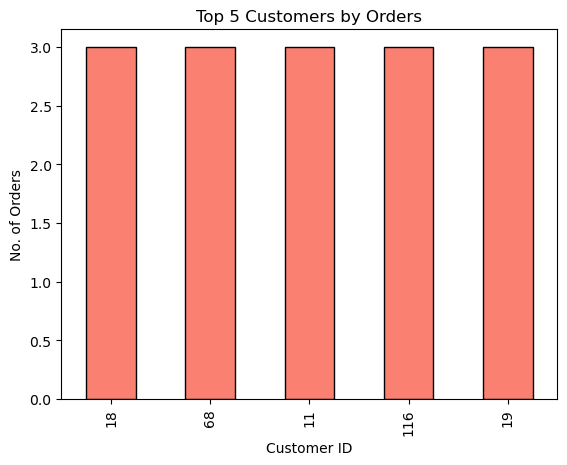

In [50]:
orders['customer_id'].value_counts().head(5).plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Top 5 Customers by Orders')
plt.xlabel('Customer ID')
plt.ylabel('No. of Orders')

Text(0, 0.5, 'Order Frequency')

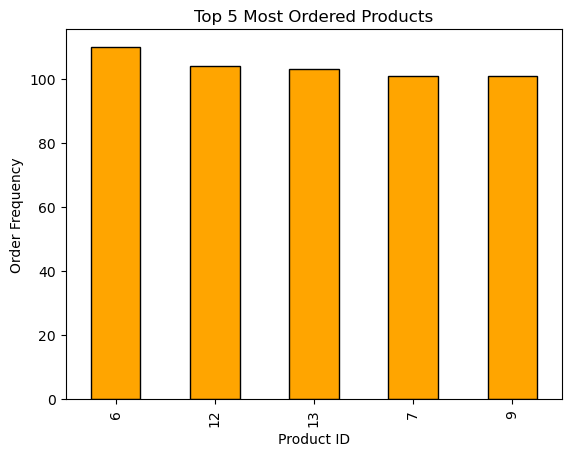

In [51]:
order_items['product_id'].value_counts().head(5).plot(kind='bar', color='orange', edgecolor='black')
plt.title('Top 5 Most Ordered Products')
plt.xlabel('Product ID')
plt.ylabel('Order Frequency')

Text(0, 0.5, 'Total Quantity')

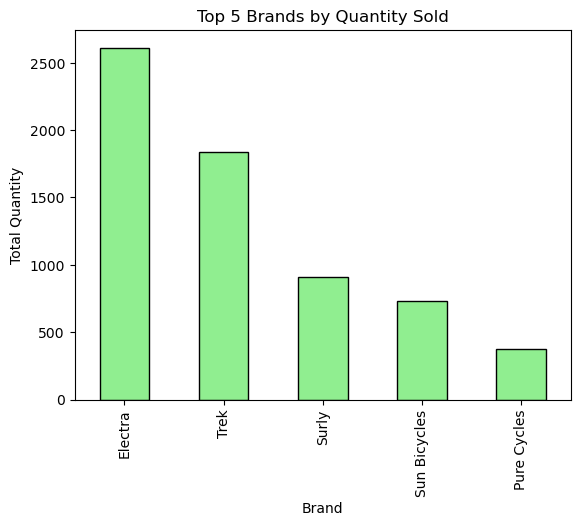

In [52]:
merged = order_items.merge(products, on='product_id').merge(brands, on='brand_id')
brand_qty = merged.groupby('brand_name')['quantity'].sum().sort_values(ascending=False).head(5)
brand_qty.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Top 5 Brands by Quantity Sold')
plt.xlabel('Brand')
plt.ylabel('Total Quantity')

Text(0, 0.5, 'Total Quantity')

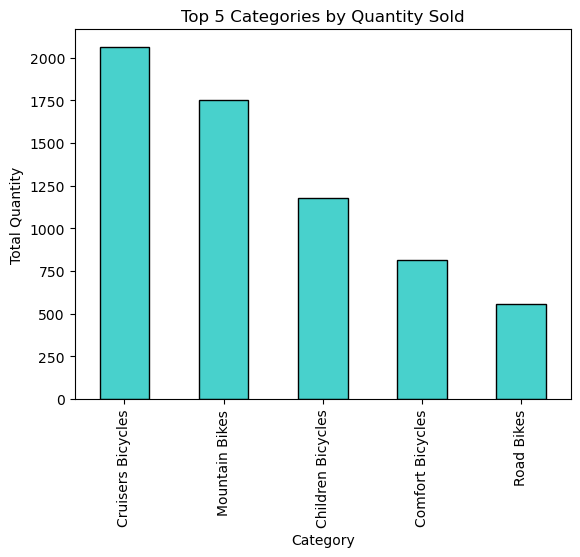

In [53]:
merged_cat = order_items.merge(products, on='product_id').merge(categories, on='category_id')
cat_qty = merged_cat.groupby('category_name')['quantity'].sum().sort_values(ascending=False).head(5)
cat_qty.plot(kind='bar', color='mediumturquoise', edgecolor='black')
plt.title('Top 5 Categories by Quantity Sold')
plt.xlabel('Category')
plt.ylabel('Total Quantity')

Text(0, 0.5, 'Total Quantity')

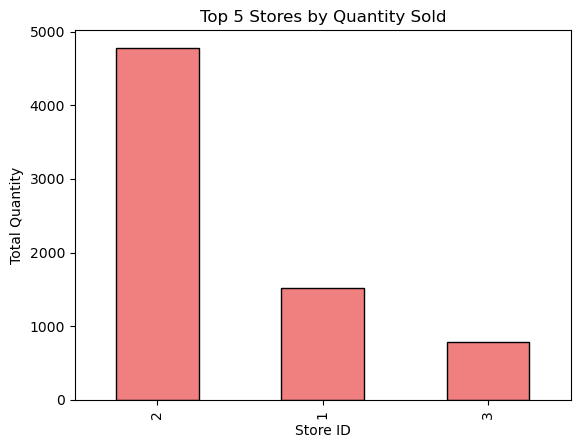

In [54]:
merged_store = order_items.merge(orders, on='order_id')
store_qty = merged_store.groupby('store_id')['quantity'].sum().sort_values(ascending=False).head(5)
store_qty.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Top 5 Stores by Quantity Sold')
plt.xlabel('Store ID')
plt.ylabel('Total Quantity')

Text(0, 0.5, 'No. of Orders')

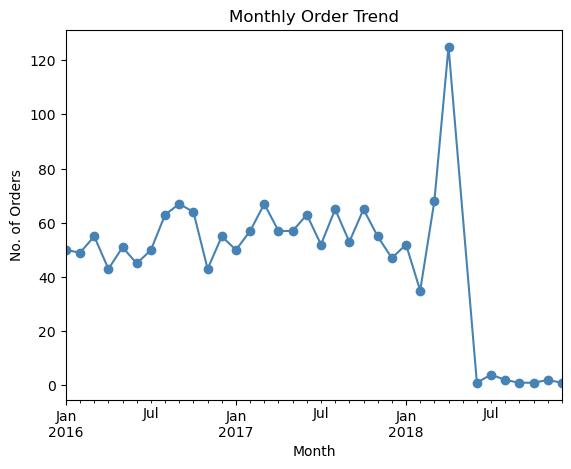

In [55]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders.groupby(orders['order_date'].dt.to_period('M')).size().plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('No. of Orders')

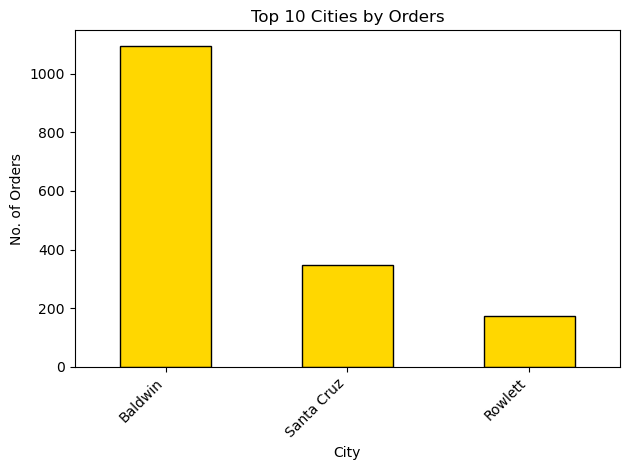

In [56]:
orders.merge(stores, on='store_id')['city'].value_counts().head(10).plot(kind='bar', color='gold', edgecolor='black')
plt.title('Top 10 Cities by Orders')
plt.xlabel('City')
plt.ylabel('No. of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [57]:
avg_qty = order_items.groupby('order_id')['quantity'].sum().mean()
print(f"Average quantity per order: {avg_qty:.2f}")

Average quantity per order: 4.38


Text(0, 0.5, 'No. of Staff')

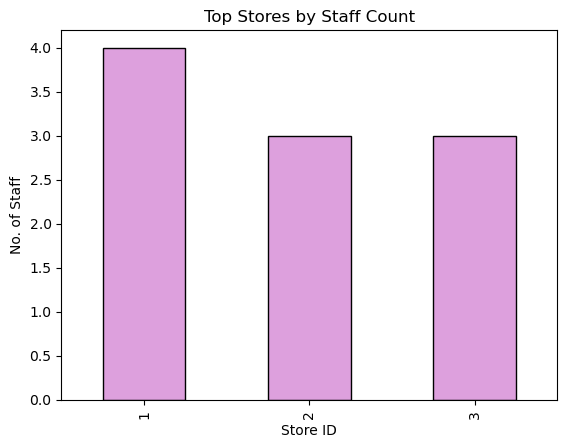

In [58]:
staffs['store_id'].value_counts().head(5).plot(kind='bar', color='plum', edgecolor='black')
plt.title('Top Stores by Staff Count')
plt.xlabel('Store ID')
plt.ylabel('No. of Staff')

Text(0, 0.5, 'Average Stock Quantity')

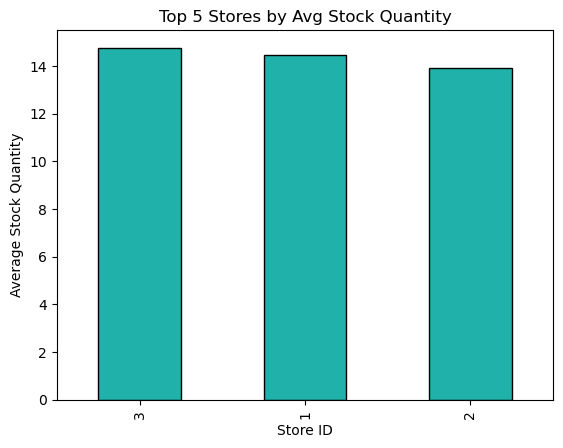

In [59]:
stocks.groupby('store_id')['quantity'].mean().sort_values(ascending=False).head(5).plot(kind='bar', color='lightseagreen', edgecolor='black')
plt.title('Top 5 Stores by Avg Stock Quantity')
plt.xlabel('Store ID')
plt.ylabel('Average Stock Quantity')

Text(0, 0.5, 'Total Stock')

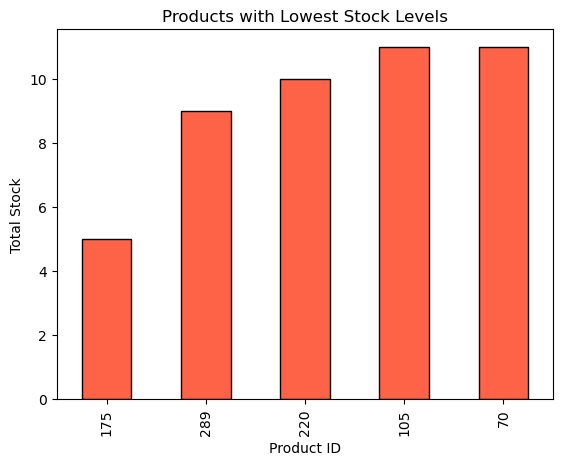

In [60]:
low_stock = stocks.groupby('product_id')['quantity'].sum().sort_values().head(5)
low_stock.plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Products with Lowest Stock Levels')
plt.xlabel('Product ID')
plt.ylabel('Total Stock')

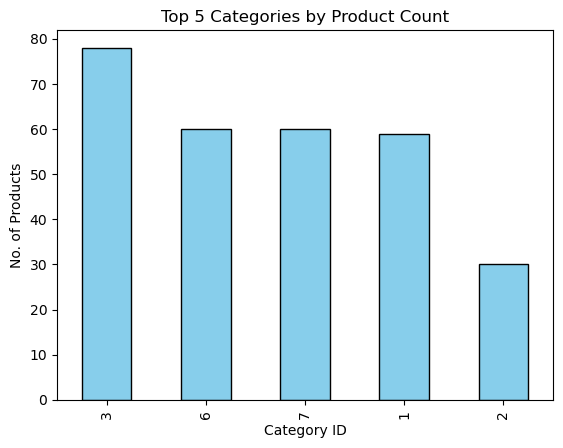

In [65]:
prod_per_cat = products.groupby('category_id')['product_id'].nunique().sort_values(ascending=False)
prod_per_cat.head(5).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 5 Categories by Product Count')
plt.xlabel('Category ID'); plt.ylabel('No. of Products'); 

In [ ]:
new

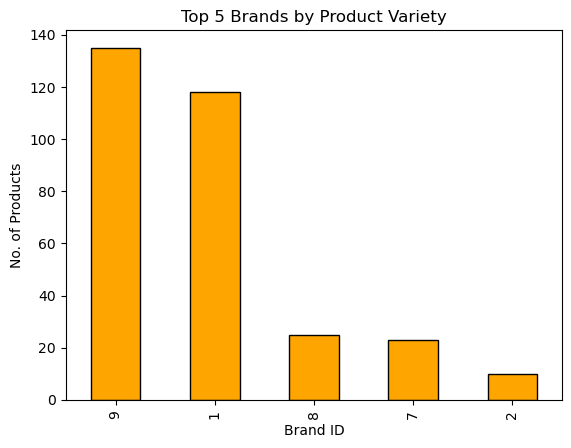

In [63]:
brand_variety = products.groupby('brand_id')['product_id'].nunique().sort_values(ascending=False)
brand_variety.head(5).plot(kind='bar', color='orange', edgecolor='black')
plt.title('Top 5 Brands by Product Variety')
plt.xlabel('Brand ID'); plt.ylabel('No. of Products');

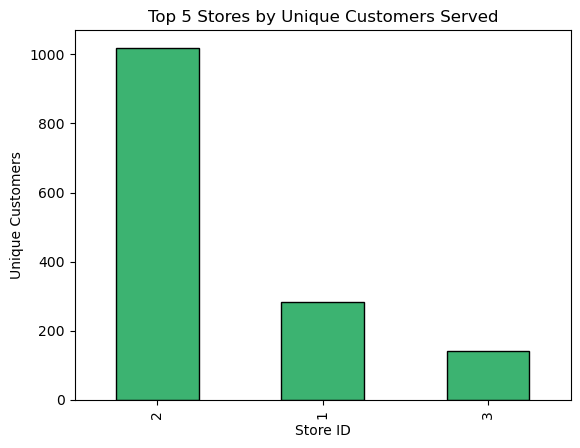

In [64]:
store_customers = orders.groupby('store_id')['customer_id'].nunique().sort_values(ascending=False)
store_customers.head(5).plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Top 5 Stores by Unique Customers Served')
plt.xlabel('Store ID'); plt.ylabel('Unique Customers'); 

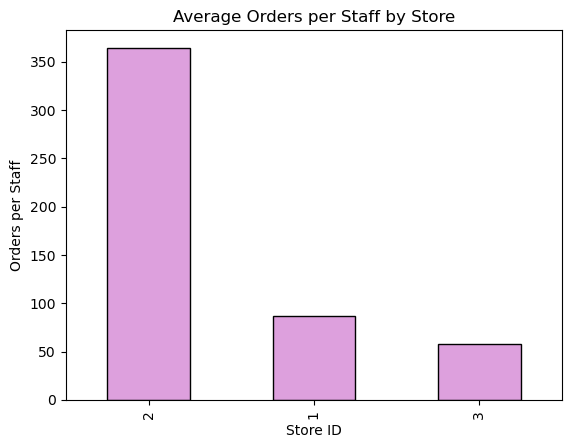

In [66]:
avg_orders_per_staff = orders.groupby('store_id')['order_id'].count() / staffs.groupby('store_id')['staff_id'].count()
avg_orders_per_staff.sort_values(ascending=False).head(5).plot(kind='bar', color='plum', edgecolor='black')
plt.title('Average Orders per Staff by Store')
plt.xlabel('Store ID'); plt.ylabel('Orders per Staff');

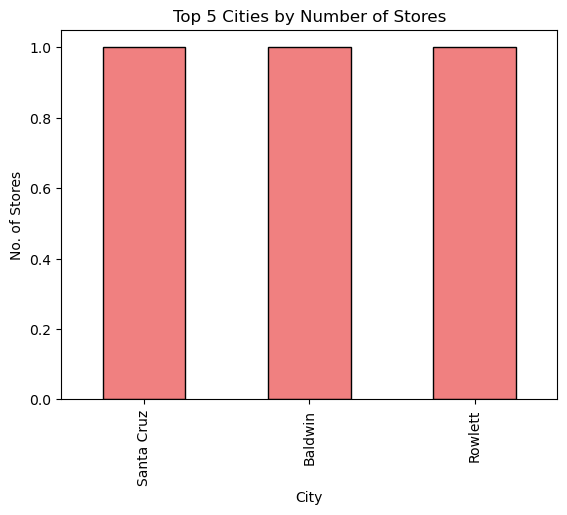

In [67]:
stores['city'].value_counts().head(5).plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Top 5 Cities by Number of Stores')
plt.xlabel('City'); plt.ylabel('No. of Stores');

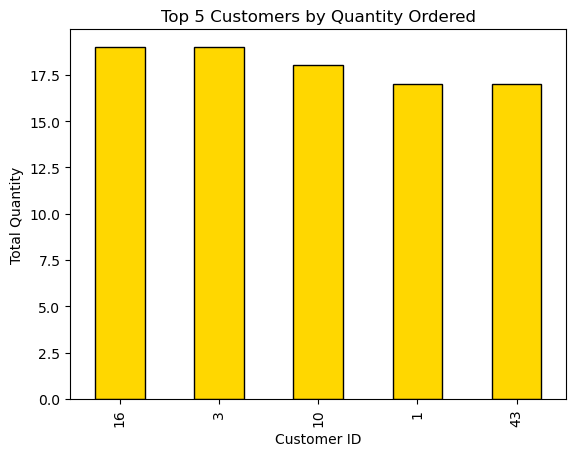

In [68]:
cust_qty = orders.merge(order_items, on='order_id').groupby('customer_id')['quantity'].sum().sort_values(ascending=False)
cust_qty.head(5).plot(kind='bar', color='gold', edgecolor='black')
plt.title('Top 5 Customers by Quantity Ordered')
plt.xlabel('Customer ID'); plt.ylabel('Total Quantity'); 

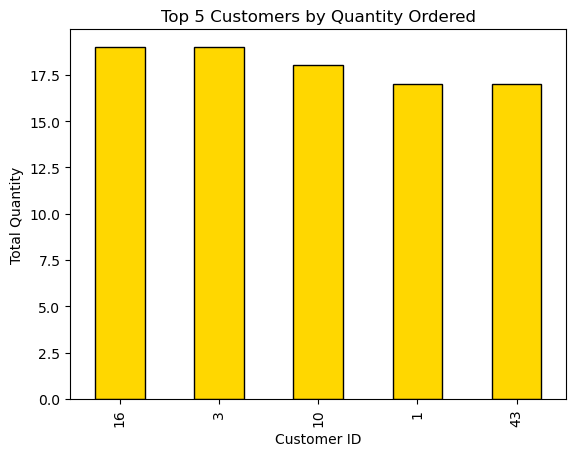

In [69]:
cust_qty = orders.merge(order_items, on='order_id').groupby('customer_id')['quantity'].sum().sort_values(ascending=False)
cust_qty.head(5).plot(kind='bar', color='gold', edgecolor='black')
plt.title('Top 5 Customers by Quantity Ordered')
plt.xlabel('Customer ID'); plt.ylabel('Total Quantity'); 

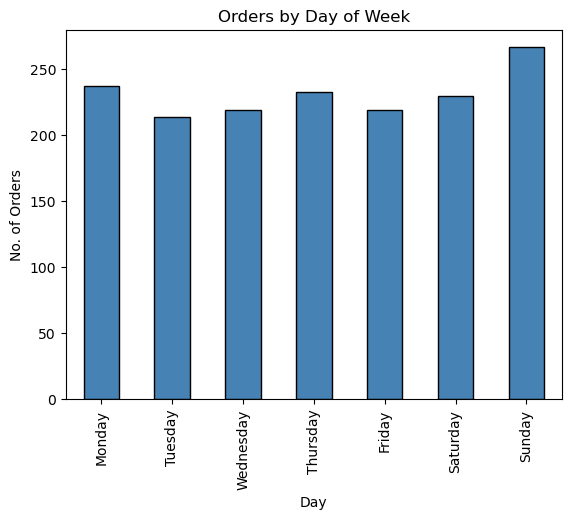

In [70]:
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
dow = orders['order_date'].dt.day_name().value_counts()
dow.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Orders by Day of Week'); plt.xlabel('Day'); plt.ylabel('No. of Orders'); 

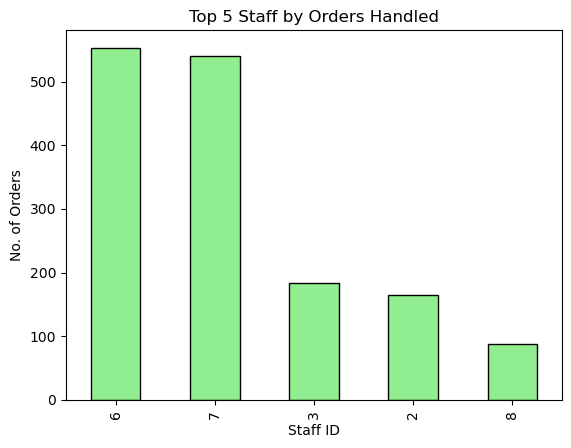

In [72]:
orders['staff_id'].value_counts().head(5).plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Top 5 Staff by Orders Handled')
plt.xlabel('Staff ID'); plt.ylabel('No. of Orders'); 

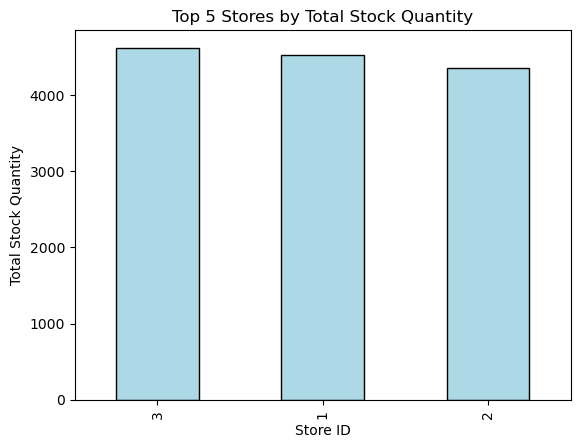

In [73]:
store_stock = stocks.groupby('store_id')['quantity'].sum().sort_values(ascending=False)
store_stock.head(5).plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Top 5 Stores by Total Stock Quantity')
plt.xlabel('Store ID'); plt.ylabel('Total Stock Quantity'); 

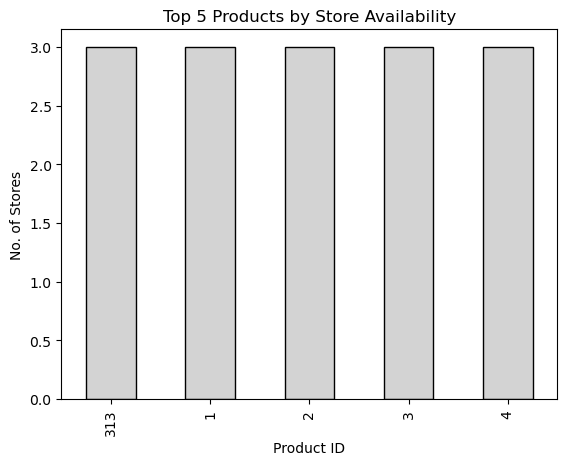

In [74]:
prod_store_count = stocks.groupby('product_id')['store_id'].nunique().sort_values(ascending=False)
prod_store_count.head(5).plot(kind='bar', color='lightgray', edgecolor='black')
plt.title('Top 5 Products by Store Availability')
plt.xlabel('Product ID'); plt.ylabel('No. of Stores'); 

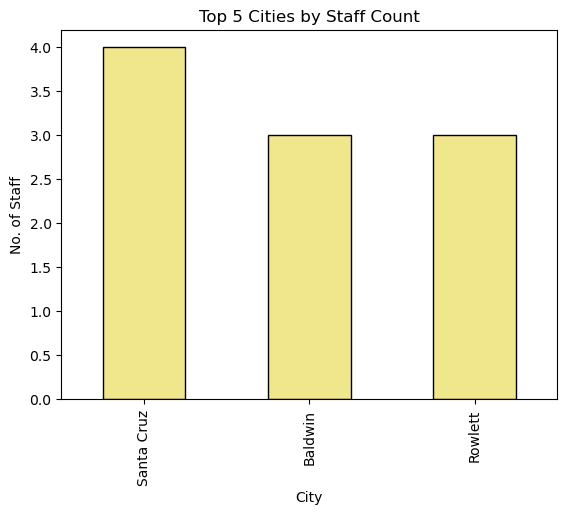

In [75]:
staff_city = staffs.merge(stores, on='store_id').groupby('city')['staff_id'].count().sort_values(ascending=False)
staff_city.head(5).plot(kind='bar', color='khaki', edgecolor='black')
plt.title('Top 5 Cities by Staff Count')
plt.xlabel('City'); plt.ylabel('No. of Staff'); 

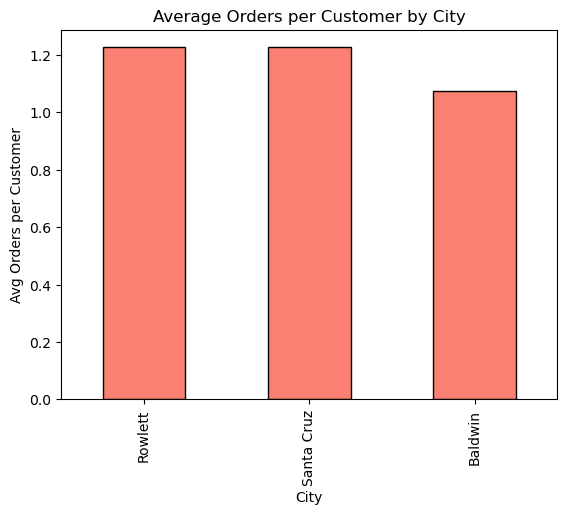

In [76]:
orders_stores = orders.merge(stores, on='store_id')
city_avg_orders = orders_stores.groupby('city')['customer_id'].count() / orders_stores.groupby('city')['customer_id'].nunique()
city_avg_orders.sort_values(ascending=False).head(5).plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Average Orders per Customer by City')
plt.xlabel('City'); plt.ylabel('Avg Orders per Customer'); 

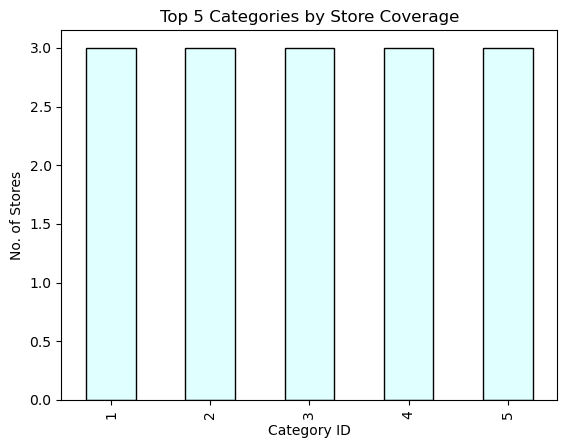

In [77]:
cat_store = stocks.merge(products, on='product_id').merge(categories, on='category_id')
cat_store.groupby('category_id')['store_id'].nunique().sort_values(ascending=False).head(5).plot(kind='bar', color='lightcyan', edgecolor='black')
plt.title('Top 5 Categories by Store Coverage')
plt.xlabel('Category ID'); plt.ylabel('No. of Stores'); 

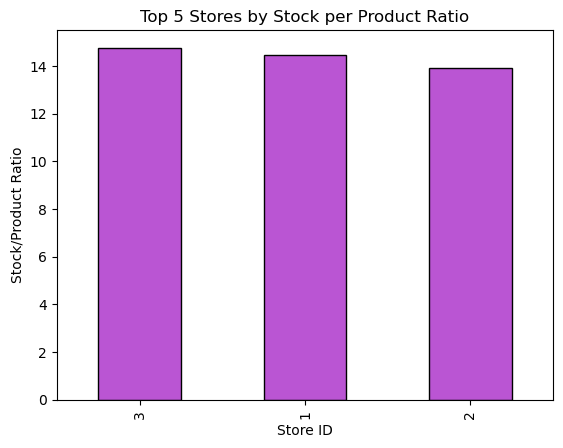

In [78]:
ratio = stocks.groupby('store_id')['quantity'].sum() / stocks.groupby('store_id')['product_id'].nunique()
ratio.sort_values(ascending=False).head(5).plot(kind='bar', color='mediumorchid', edgecolor='black')
plt.title('Top 5 Stores by Stock per Product Ratio')
plt.xlabel('Store ID'); plt.ylabel('Stock/Product Ratio'); 

In [ ]:
advanced

In [79]:
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
merged = orders.merge(order_items, on='order_id').merge(products, on='product_id').merge(categories, on='category_id')

cat_month = merged.groupby([merged['order_date'].dt.to_period('M'), 'category_id'])['quantity'].sum().unstack().fillna(0)
cat_growth = cat_month.pct_change().mean().sort_values(ascending=False)
cat_growth.head(5)

category_id
1    inf
2    inf
3    inf
5    inf
6    inf
dtype: float64

In [80]:
store_month = orders.merge(order_items, on='order_id')
store_month['order_date'] = pd.to_datetime(store_month['order_date'], errors='coerce')
trend = store_month.groupby([store_month['order_date'].dt.to_period('M'), 'store_id'])['quantity'].sum().unstack().fillna(0)
trend.var().sort_values().head(5)

store_id
3     301.475630
1    1528.280672
2    5773.490756
dtype: float64

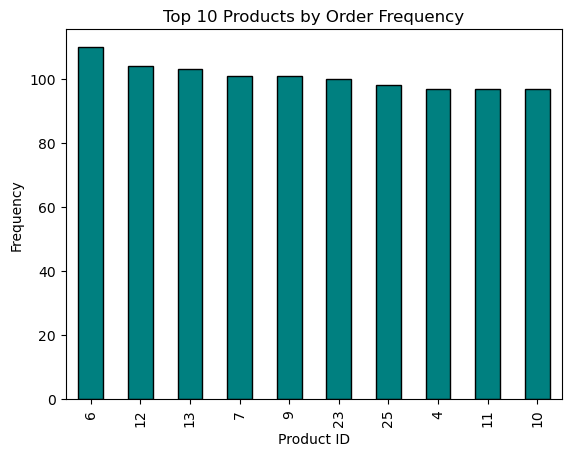

In [81]:
prod_freq = order_items['product_id'].value_counts().head(10)
prod_freq.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 10 Products by Order Frequency')
plt.xlabel('Product ID'); plt.ylabel('Frequency'); 

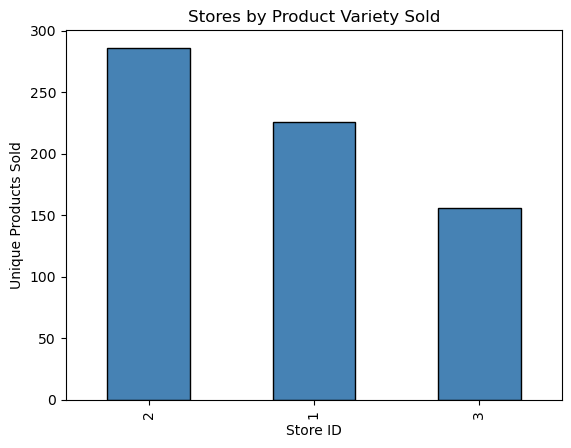

In [82]:
orders_items_store = order_items.merge(orders, on='order_id')
prod_range = orders_items_store.groupby('store_id')['product_id'].nunique().sort_values(ascending=False)
prod_range.head(5).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Stores by Product Variety Sold')
plt.xlabel('Store ID'); plt.ylabel('Unique Products Sold'); 

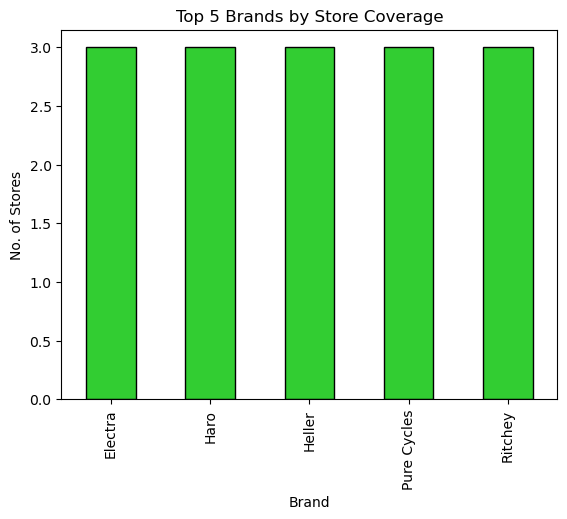

In [83]:
brand_spread = stocks.merge(products, on='product_id').merge(brands, on='brand_id')
brand_spread.groupby('brand_name')['store_id'].nunique().sort_values(ascending=False).head(5).plot(kind='bar', color='limegreen', edgecolor='black')
plt.title('Top 5 Brands by Store Coverage')
plt.xlabel('Brand'); plt.ylabel('No. of Stores'); 

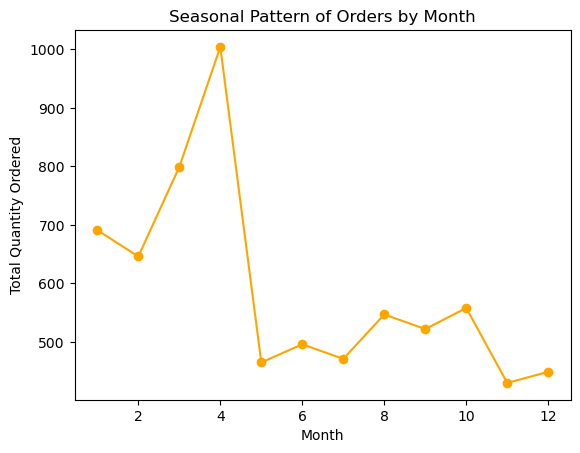

In [84]:
orders['month'] = orders['order_date'].dt.month
orders.merge(order_items, on='order_id').groupby('month')['quantity'].sum().plot(kind='line', marker='o', color='orange')
plt.title('Seasonal Pattern of Orders by Month')
plt.xlabel('Month'); plt.ylabel('Total Quantity Ordered'); 

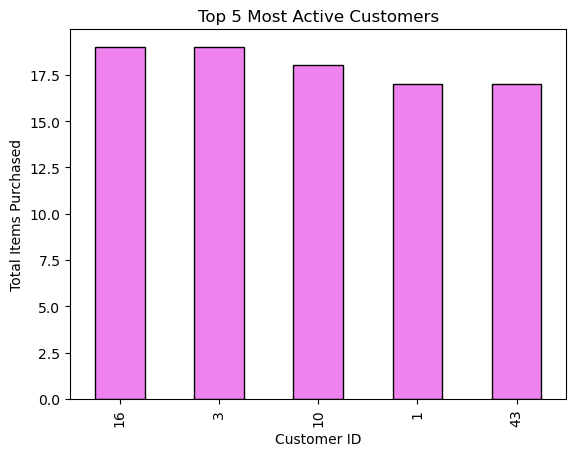

In [85]:
cust_activity = orders.merge(order_items, on='order_id').groupby('customer_id')['quantity'].sum().sort_values(ascending=False)
cust_activity.head(5).plot(kind='bar', color='violet', edgecolor='black')
plt.title('Top 5 Most Active Customers')
plt.xlabel('Customer ID'); plt.ylabel('Total Items Purchased'); 

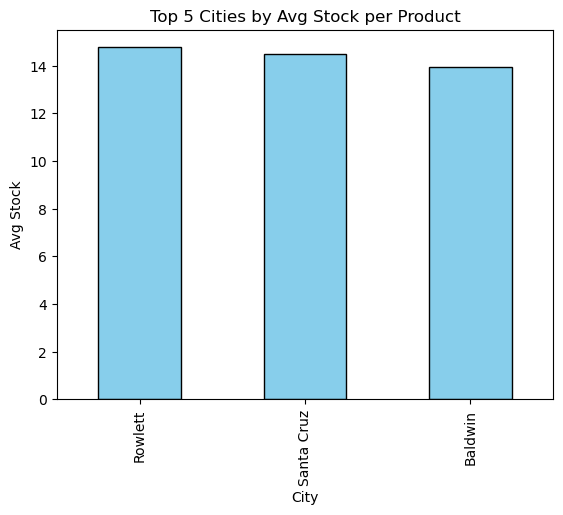

In [86]:
city_stock = stocks.merge(stores, on='store_id')
avg_stock = city_stock.groupby('city')['quantity'].mean().sort_values(ascending=False)
avg_stock.head(5).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 5 Cities by Avg Stock per Product')
plt.xlabel('City'); plt.ylabel('Avg Stock'); 

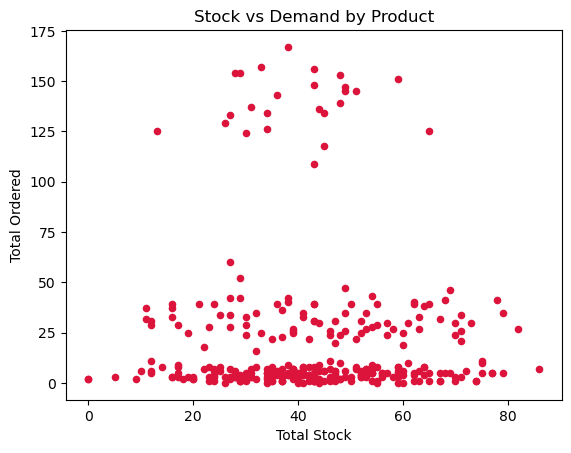

In [87]:
sales_qty = order_items.groupby('product_id')['quantity'].sum()
stock_qty = stocks.groupby('product_id')['quantity'].sum()
compare = pd.DataFrame({'Total_Stock': stock_qty, 'Total_Ordered': sales_qty}).fillna(0)
compare.plot(kind='scatter', x='Total_Stock', y='Total_Ordered', color='crimson')
plt.title('Stock vs Demand by Product'); plt.xlabel('Total Stock'); plt.ylabel('Total Ordered'); 

In [88]:
cust_orders = orders.groupby('customer_id')['order_id'].count()
cust_qty = orders.merge(order_items, on='order_id').groupby('customer_id')['quantity'].sum()
corr = pd.concat([cust_orders, cust_qty], axis=1, keys=['Orders', 'Quantity'])
corr.corr()

,Orders,Quantity
Orders,1.000000,0.598412
Quantity,0.598412,1.000000


In [89]:
merged_cat = orders.merge(order_items, on='order_id').merge(products, on='product_id').merge(categories, on='category_id')
trend = merged_cat.groupby([merged_cat['order_date'].dt.to_period('M'), 'category_id'])['quantity'].sum().unstack().fillna(0)
decliners = trend.pct_change().mean().sort_values().head(5)
decliners

category_id
4    0.200899
1         inf
2         inf
3         inf
5         inf
dtype: float64

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Forecasted order counts for next 3 months: [25. 24. 23.]


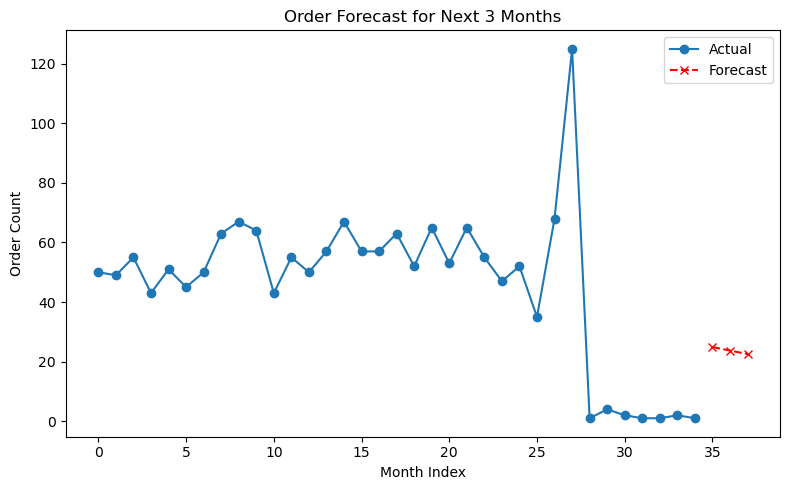

In [92]:
from sklearn.linear_model import LinearRegression

orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
orders = orders.dropna(subset=['order_date'])
monthly_orders = (
    orders.groupby(orders['order_date'].dt.to_period('M'))['order_id']
    .count()
    .reset_index()
)
monthly_orders['month_period'] = monthly_orders['order_date'].astype(str)
monthly_orders['month_num'] = np.arange(len(monthly_orders))
model = LinearRegression()
model.fit(monthly_orders[['month_num']], monthly_orders['order_id'])
future_months = np.arange(len(monthly_orders), len(monthly_orders) + 3).reshape(-1, 1)
forecast = model.predict(future_months)
print("Forecasted order counts for next 3 months:", np.round(forecast, 0))
plt.figure(figsize=(8,5))
plt.plot(monthly_orders['month_num'], monthly_orders['order_id'], marker='o', label='Actual')
plt.plot(future_months, forecast, marker='x', linestyle='--', color='red', label='Forecast')
plt.title('Order Forecast for Next 3 Months')
plt.xlabel('Month Index')
plt.ylabel('Order Count')
plt.legend()
plt.tight_layout()